In [63]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import os
from PIL import Image

from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf 
from tensorflow.keras.layers  import Dense ,Conv2D ,Activation , Dropout , BatchNormalization , ReLU , MaxPooling2D , Flatten 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau , ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')


In [18]:
data_dir = '/kaggle/input/plantvillage-dataset/color'
label = []
image_path = []
folds = os.listdir(data_dir)
for fold in folds :
    folder_path = os.path.join(data_dir , fold)
    imgs = os.listdir(folder_path)
    for img in imgs : 
        img_path = os.path.join(folder_path , img)
        label.append(fold)
        image_path.append(img_path)
print("Total images:", len(image_path))
print("Total labels:", len(label))

Total images: 54305
Total labels: 54305


In [21]:
paths_df = pd.Series(image_path)
label_df = pd.Series(label)

data = pd.DataFrame(
    {
        "imagepaths" :paths_df,
        "label" : label_df
    }
)

In [22]:
data.head()

,imagepaths,label
0,/kaggle/input/plantvillage-dataset/color/Tomat...,Tomato___Late_blight
1,/kaggle/input/plantvillage-dataset/color/Tomat...,Tomato___Late_blight
2,/kaggle/input/plantvillage-dataset/color/Tomat...,Tomato___Late_blight
3,/kaggle/input/plantvillage-dataset/color/Tomat...,Tomato___Late_blight
4,/kaggle/input/plantvillage-dataset/color/Tomat...,Tomato___Late_blight


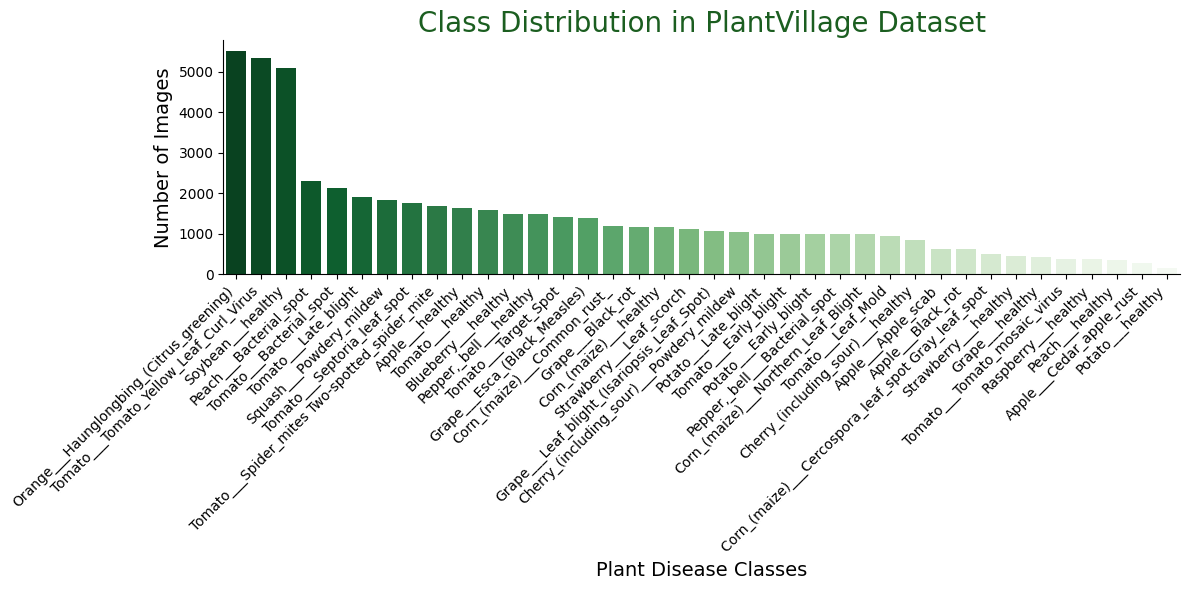

In [24]:
label_counts = data.label.value_counts().reset_index()
label_counts.columns = ['Label', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=label_counts,
    x="Label",
    y="Count",
    palette="Greens_r"  
)
plt.title("Class Distribution in PlantVillage Dataset", fontsize=20, color="#1b5e20")
plt.xlabel("Plant Disease Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()


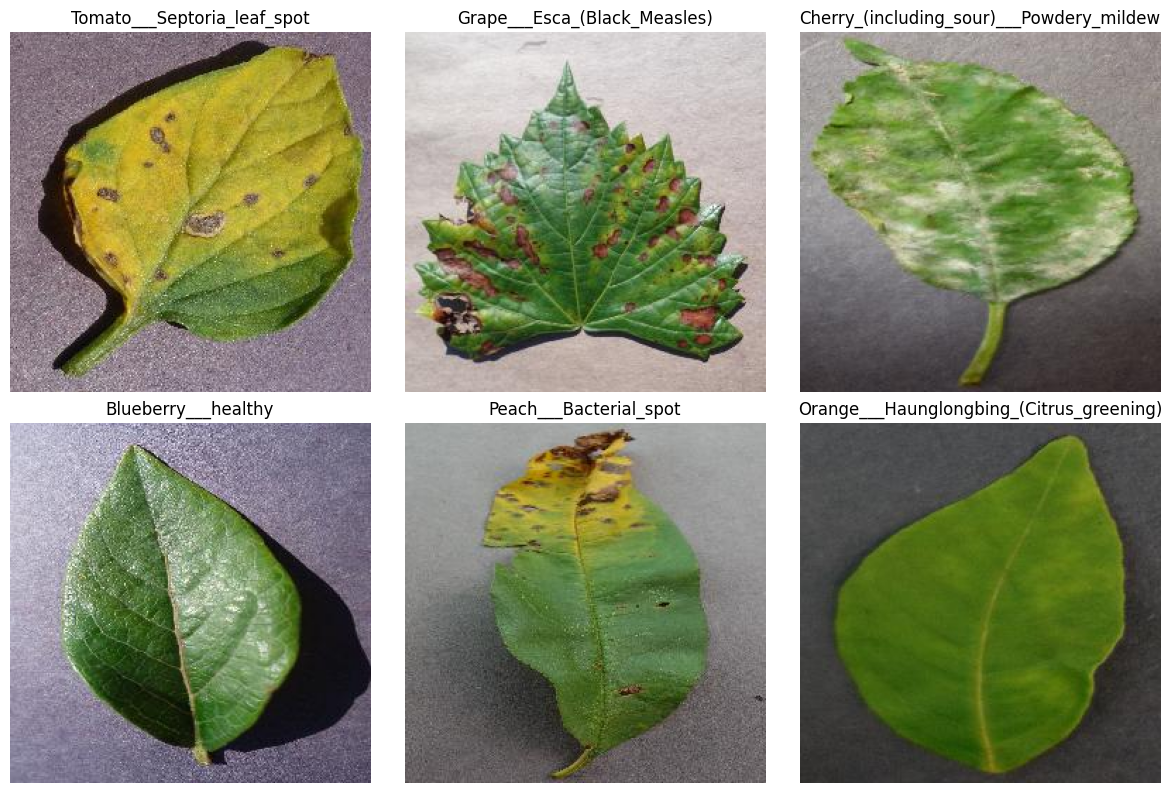

In [33]:
plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    rand_idx = np.random.randint(0, len(data))
    img_path = data.iloc[rand_idx]['imagepaths']
    lbl = data.iloc[rand_idx]['label']
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(lbl)
    plt.axis('off')

plt.tight_layout()
plt.show()
    

In [34]:
train_data, damy_data = train_test_split(data, test_size=0.2, shuffle=True, stratify=data['label'], random_state=42)
valid_data, test_data = train_test_split(damy_data, test_size=0.5, shuffle=True, stratify=damy_data['label'], random_state=42)

In [35]:
print(len(train_data.label.value_counts()))
print(len(test_data.label.value_counts()))
print(len(valid_data.label.value_counts()))

38
38
38


In [46]:
image_size = 224
batch_size = 32 
channel = 3 

In [39]:
train_datagen = ImageDataGenerator(
    rescale = 1./255 , 
    rotation_range=40,
    width_shift_range = 0.2 , 
    height_shift_range = 0.2 , 
    shear_range = 0.2 , 
    zoom_range = 0.2 , 
    horizontal_flip=True,
     fill_mode='nearest'
)
test_datagen=ImageDataGenerator(rescale=1./255,)

In [40]:
train_gen=train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='imagepaths',
    y_col='label',
    batch_size=batch_size,
    class_mode='categorical',
    target_size=(image_size,image_size),
    shuffle=True
)


Found 43444 validated image filenames belonging to 38 classes.


In [41]:
valid_gen=test_datagen.flow_from_dataframe(
    dataframe=valid_data,
    x_col='imagepaths',
    y_col='label',
    class_mode='categorical',
    batch_size=batch_size,
    target_size=(image_size,image_size),
    shuffle=False
    
)

Found 5430 validated image filenames belonging to 38 classes.


In [43]:
test_gen=test_datagen.flow_from_dataframe(
    dataframe=test_data,
    x_col='imagepaths',
    y_col='label',
    batch_size=batch_size,
    class_mode='categorical',
    target_size=(image_size,image_size),
    shuffle=False
    
)

Found 5431 validated image filenames belonging to 38 classes.


In [44]:
train_gen.class_indices.items()

dict_items([('Apple___Apple_scab', 0), ('Apple___Black_rot', 1), ('Apple___Cedar_apple_rust', 2), ('Apple___healthy', 3), ('Blueberry___healthy', 4), ('Cherry_(including_sour)___Powdery_mildew', 5), ('Cherry_(including_sour)___healthy', 6), ('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 7), ('Corn_(maize)___Common_rust_', 8), ('Corn_(maize)___Northern_Leaf_Blight', 9), ('Corn_(maize)___healthy', 10), ('Grape___Black_rot', 11), ('Grape___Esca_(Black_Measles)', 12), ('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 13), ('Grape___healthy', 14), ('Orange___Haunglongbing_(Citrus_greening)', 15), ('Peach___Bacterial_spot', 16), ('Peach___healthy', 17), ('Pepper,_bell___Bacterial_spot', 18), ('Pepper,_bell___healthy', 19), ('Potato___Early_blight', 20), ('Potato___Late_blight', 21), ('Potato___healthy', 22), ('Raspberry___healthy', 23), ('Soybean___healthy', 24), ('Squash___Powdery_mildew', 25), ('Strawberry___Leaf_scorch', 26), ('Strawberry___healthy', 27), ('Tomato___Bacterial_spot', 

In [51]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), padding='same', input_shape=(image_size, image_size, channel)),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2,2)),
    Dropout(0.2),

    # Fully connected
    Flatten(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(len(train_gen.class_indices), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


I0000 00:00:1763755501.833989      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             

 Total params: 26,046,310 (99.36 MB)

 Trainable params: 26,044,582 (99.35 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [54]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=2, monitor='val_loss', verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)
]


In [55]:
history=model.fit(train_gen,epochs=25,validation_data=valid_gen,callbacks=callbacks, verbose=1)

Epoch 1/25


I0000 00:00:1763756095.427764     315 service.cc:148] XLA service 0x78e89800ccc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763756095.428588     315 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763756096.344865     315 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-11-21 20:15:02.513354: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,224,224]{3,2,1,0}, f32[32,64,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-11-21 20:15:02.691303: E external/l

   2/1358 ━━━━━━━━━━━━━━━━━━━━ 2:00 89ms/step - accuracy: 0.0078 - loss: 4.6682      

I0000 00:00:1763756107.279815     315 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.4838 - loss: 1.9272
Epoch 1: val_loss improved from inf to 2.61913, saving model to best_model.h5


...

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 500s 368ms/step - accuracy: 0.7610 - loss: 0.7971 - val_accuracy: 0.7514 - val_loss: 0.8793 - learning_rate: 0.0010
Epoch 3/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8229 - loss: 0.5690
Epoch 3: val_loss did not improve from 0.87931
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 486s 358ms/step - accuracy: 0.8229 - loss: 0.5690 - val_accuracy: 0.6538 - val_loss: 1.2964 - learning_rate: 0.0010
Epoch 4/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8583 - loss: 0.4498
Epoch 4: val_loss improved from 0.87931 to 0.69394, saving model to best_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 488s 359ms/step - accuracy: 0.8583 - loss: 0.4498 - val_accuracy: 0.8068 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 5/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8772 - loss: 0.3898
Epoch 5: val_loss did not improve from 0.69394
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 478s 352ms/step - accuracy: 0.8772 - loss: 0.3898 - val_accuracy: 0.7026 - val_loss: 1.1244 - learning_rate: 0.0010
Epoch 6/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.8967 - loss: 0.3323
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 6: val_loss did not improve from 0.69394
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 485s 357ms/step - accuracy: 0.8967 - loss: 0.3323 - val_accuracy: 0.8057 - val_loss: 0.7380 - learning_rate: 0.0010
Epoch 7/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9305 - loss: 0.2277
Epoch 7: val_loss improved from 0.69394 to 0.11481, saving model to best_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 485s 357ms/step - accuracy: 0.9305 - loss: 0.2276 - val_accuracy: 0.9586 - val_loss: 0.1148 - learning_rate: 3.0000e-04
Epoch 8/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9381 - loss: 0.1956
Epoch 8: val_loss did not improve from 0.11481
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 492s 362ms/step - accuracy: 0.9381 - loss: 0.1956 - val_accuracy: 0.9328 - val_loss: 0.1980 - learning_rate: 3.0000e-04
Epoch 9/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9448 - loss: 0.1746
Epoch 9: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 9: val_loss did not improve from 0.11481
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 482s 355ms/step - accuracy: 0.9448 - loss: 0.1746 - val_accuracy: 0.9560 - val_loss: 0.1277 - learning_rate: 3.0000e-04
Epoch 10/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9545 - loss: 0.1461
Epoch 10: val_loss improved from 0.11481 to 0.07432, saving model to best_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 479s 353ms/step - accuracy: 0.9545 - loss: 0.1461 - val_accuracy: 0.9762 - val_loss: 0.0743 - learning_rate: 9.0000e-05
Epoch 11/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9620 - loss: 0.1258
Epoch 11: val_loss did not improve from 0.07432
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 484s 356ms/step - accuracy: 0.9620 - loss: 0.1258 - val_accuracy: 0.9635 - val_loss: 0.1082 - learning_rate: 9.0000e-05
Epoch 12/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9593 - loss: 0.1300
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.

Epoch 12: val_loss did not improve from 0.07432
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 489s 360ms/step - accuracy: 0.9593 - loss: 0.1300 - val_accuracy: 0.9663 - val_loss: 0.0967 - learning_rate: 9.0000e-05
Epoch 13/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9622 - loss: 0.1175
Epoch 13: val_loss improved from 0.07432 to 0.05489, saving model to best_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 475s 350ms/step - accuracy: 0.9622 - loss: 0.1175 - val_accuracy: 0.9818 - val_loss: 0.0549 - learning_rate: 2.7000e-05
Epoch 14/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9642 - loss: 0.1157
Epoch 14: val_loss did not improve from 0.05489
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 496s 365ms/step - accuracy: 0.9642 - loss: 0.1157 - val_accuracy: 0.9801 - val_loss: 0.0617 - learning_rate: 2.7000e-05
Epoch 15/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9659 - loss: 0.1094
Epoch 15: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.

Epoch 15: val_loss did not improve from 0.05489
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 486s 358ms/step - accuracy: 0.9659 - loss: 0.1094 - val_accuracy: 0.9779 - val_loss: 0.0665 - learning_rate: 2.7000e-05
Epoch 16/25
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9639 - loss: 0.1153
Epoch 16: val_loss did not improve from 0.05489
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 506s 372ms/step - acc

In [56]:
loss_train,accuracy_train=model.evaluate(train_gen)
loss_valid,accuracy_valid=model.evaluate(valid_gen)
loss_test,accuracy_test=model.evaluate(test_gen)

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 461s 340ms/step - accuracy: 0.9894 - loss: 0.0354
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.9773 - loss: 0.0669
170/170 ━━━━━━━━━━━━━━━━━━━━ 41s 244ms/step - accuracy: 0.9777 - loss: 0.0663


In [57]:
print(f'Loss Train: {loss_train},Accuracy Train: {accuracy_train}')
print(f'Loss Valid: {loss_valid},Accuracy Valid: {accuracy_valid}')
print(f'Loss Test: {loss_test},Accuracy Test: {accuracy_test}')

Loss Train: 0.036873143166303635,Accuracy Train: 0.9889052510261536
Loss Valid: 0.05489185079932213,Accuracy Valid: 0.9817679524421692
Loss Test: 0.051615625619888306,Accuracy Test: 0.9830601811408997


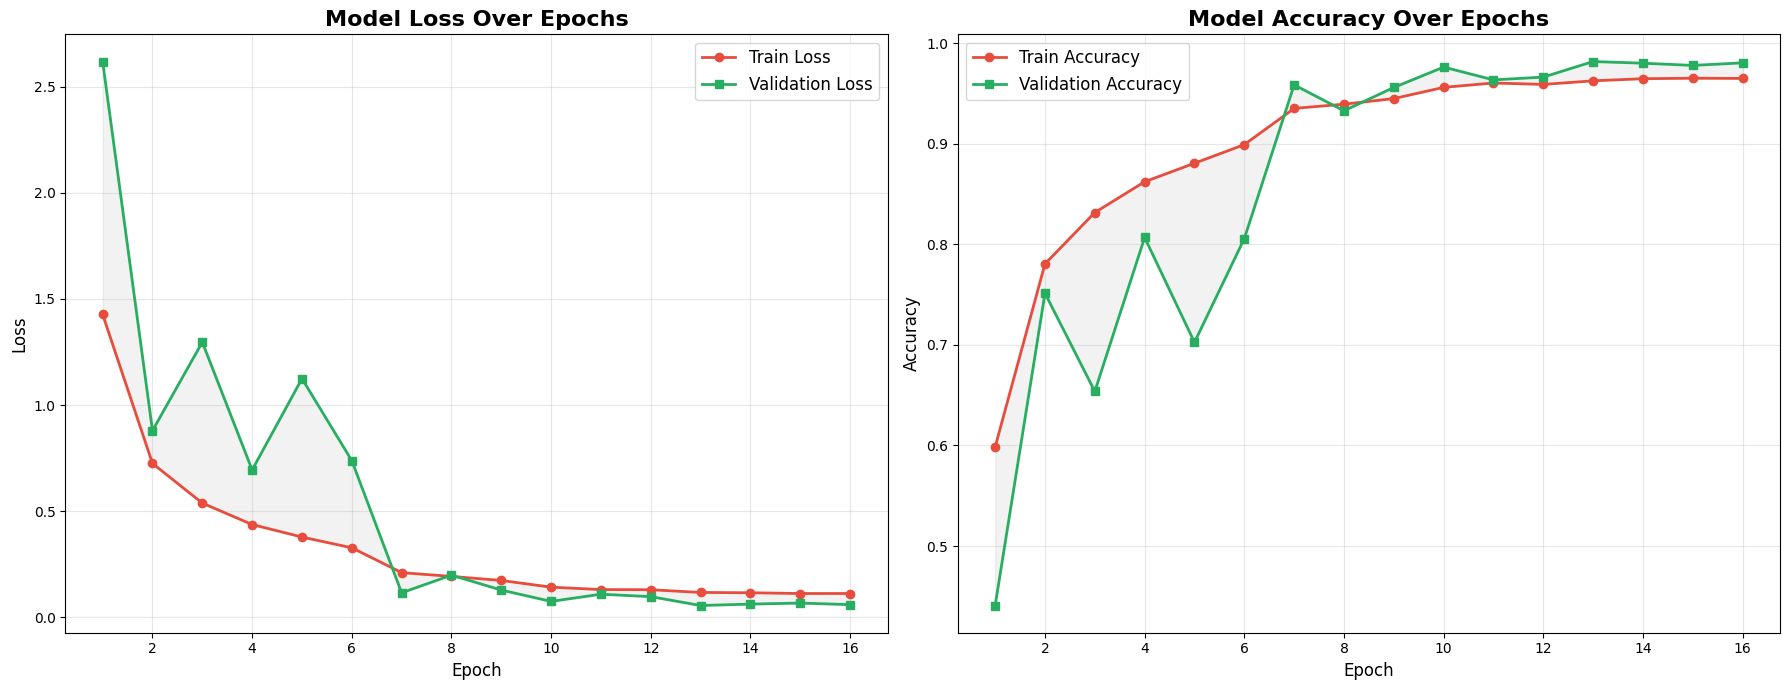

In [58]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(tr_acc) + 1)

plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, color='#E74C3C', linewidth=2, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, color='#27AE60', linewidth=2, marker='s', label='Validation Loss')
plt.fill_between(epochs, val_loss, tr_loss, color='gray', alpha=0.1)  
plt.title('Model Loss Over Epochs', fontsize=16, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_acc, color='#E74C3C', linewidth=2, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, color='#27AE60', linewidth=2, marker='s', label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs', fontsize=16, weight='bold')
plt.fill_between(epochs, val_acc, tr_acc, color='gray', alpha=0.1)  
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)


plt.tight_layout()
plt.show()


In [59]:
def preprocess(img_path, target_size=(224, 224)):
    img = Image.open(img_path)
    resized = img.resize(target_size)
    img_array = np.array(resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') / 255.
    return img_array

In [60]:
def prediction(model,img_path,class_indices):
  preprocessed_img = preprocess(img_path)
  predictions = model.predict(preprocessed_img)
  predicted_class_index = np.argmax(predictions, axis=1)[0]
  predicted_class_name = class_indices[predicted_class_index]
  return predicted_class_name

In [61]:
class_indices = {v: k for k, v in train_gen.class_indices.items()}
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [65]:
image_path = '/kaggle/input/plantvillage-dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'
predicted_class_name = prediction(model, image_path, class_indices)
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class Name: Apple___Apple_scab


In [67]:
image_path = '/kaggle/input/plantvillage-dataset/color/Squash___Powdery_mildew/0045a100-36d3-45df-b417-d487d6e07eb4___UMD_Powd.M 0003.JPG'
predicted_class_name = prediction(model, image_path, class_indices)
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Class Name: Squash___Powdery_mildew


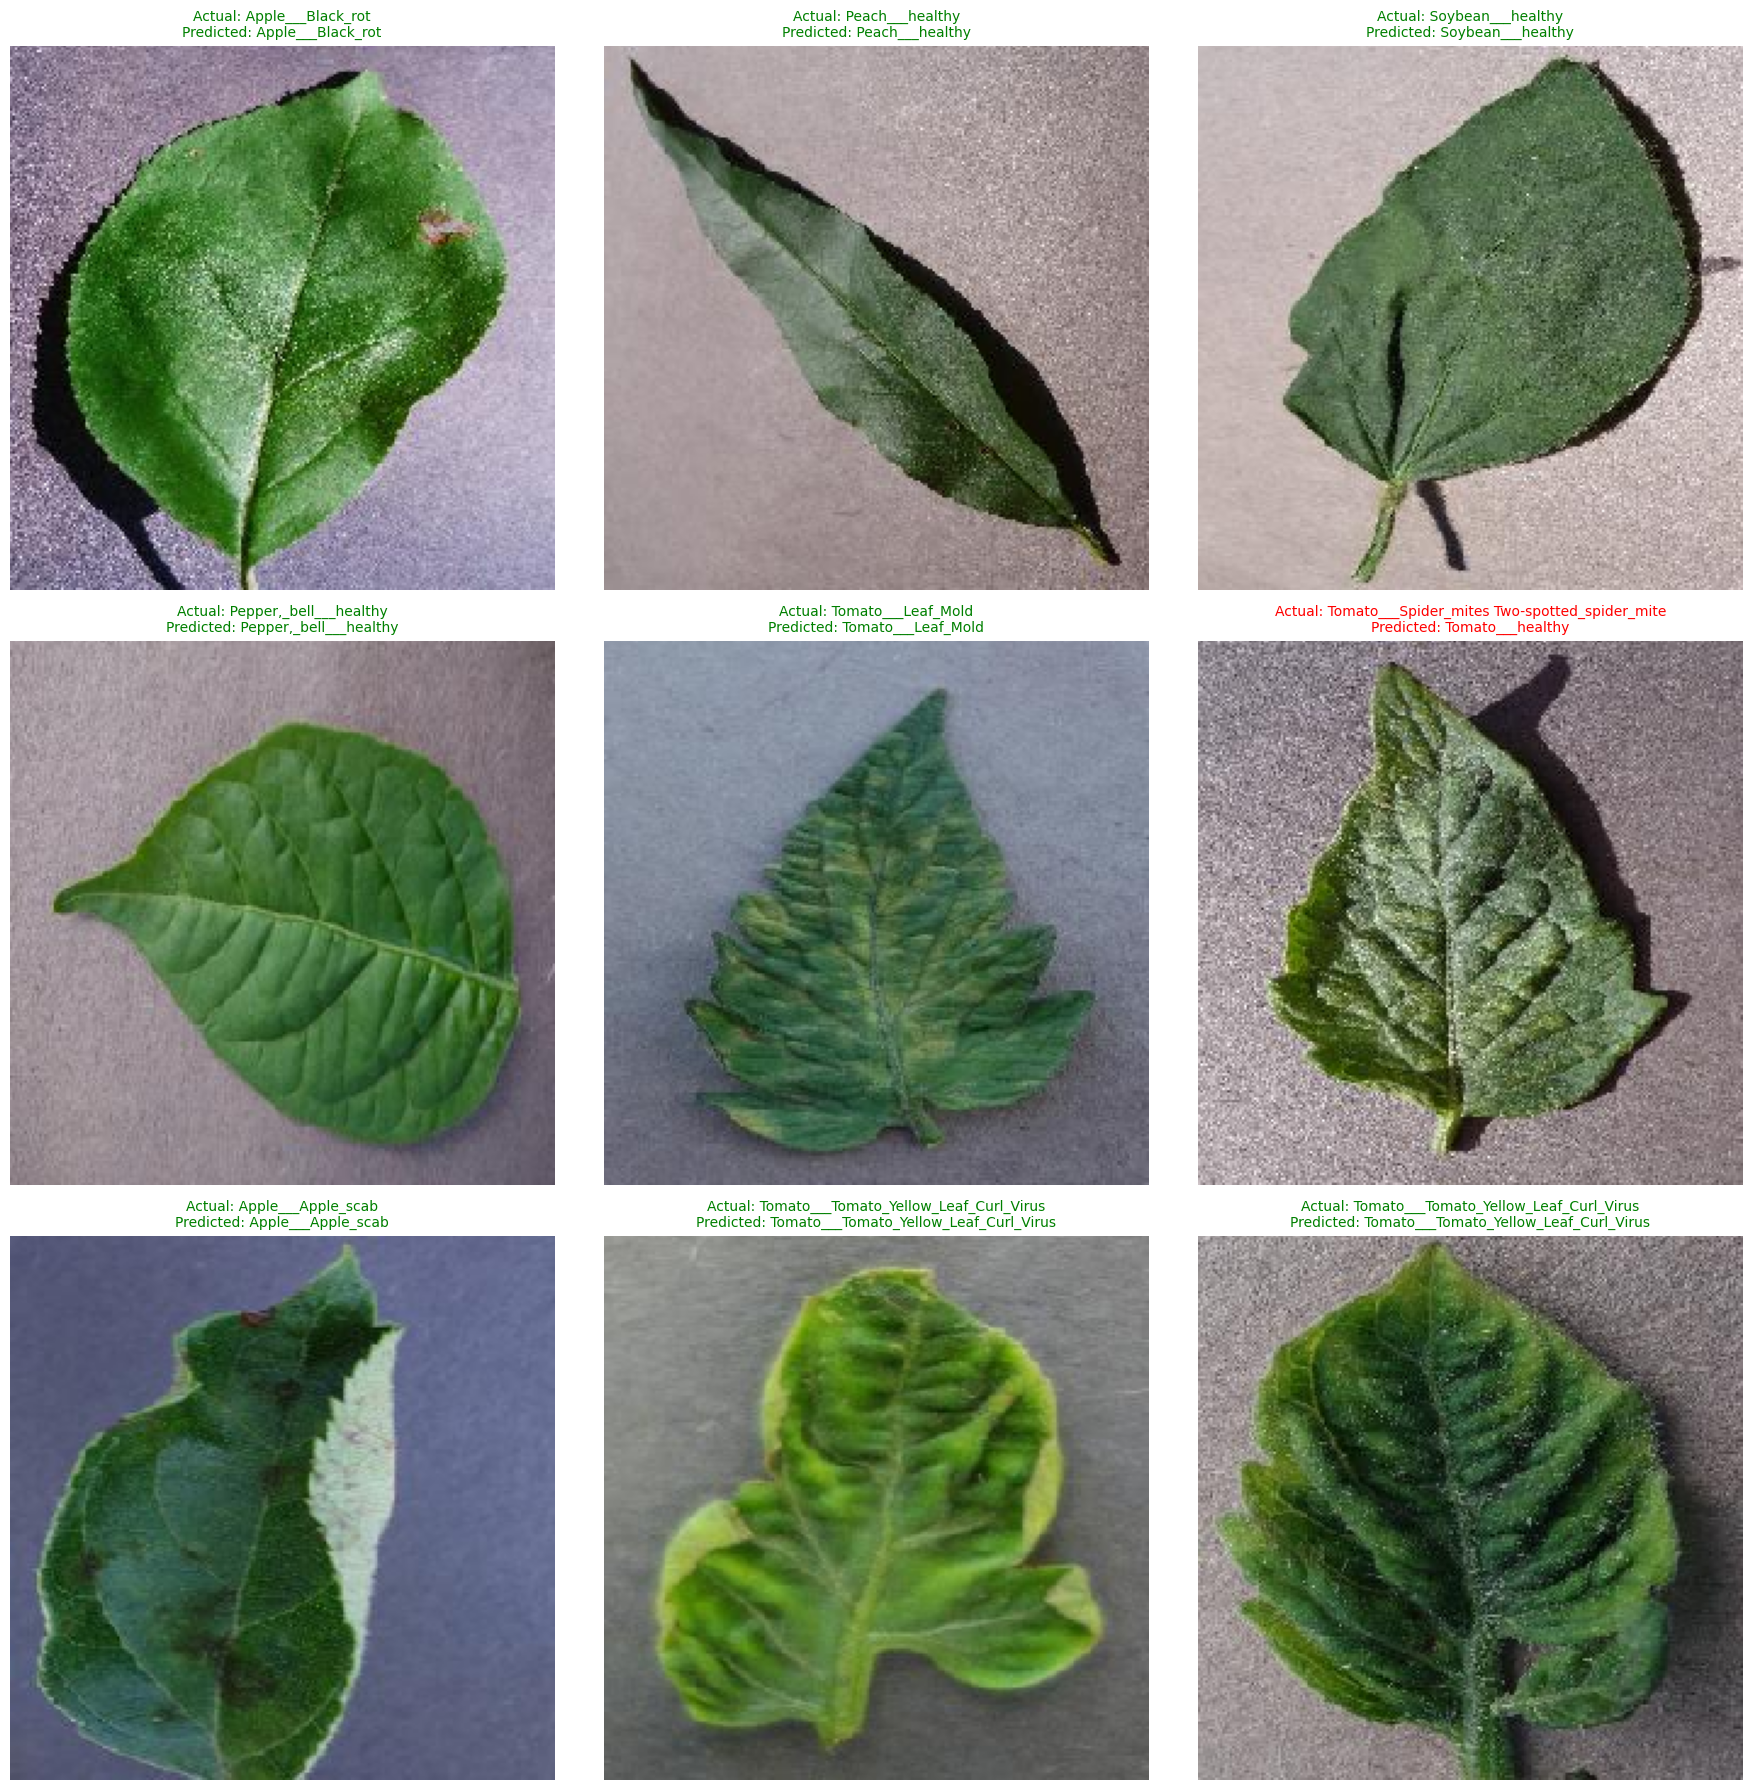

In [68]:
plt.figure(figsize=(18,18))

images, labels = next(test_gen)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

    true_label_idx = np.argmax(labels[i])
    actual = class_indices[true_label_idx]

    preds = model.predict(np.expand_dims(images[i], axis=0), verbose=0)
    pred_label_idx = np.argmax(preds)
    predict = class_indices[pred_label_idx]

    color = 'green' if actual == predict else 'red' #ternnary statement 
    plt.title(f"Actual: {actual}\nPredicted: {predict}", color=color, fontsize=10)

plt.tight_layout()
plt.show()


170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step


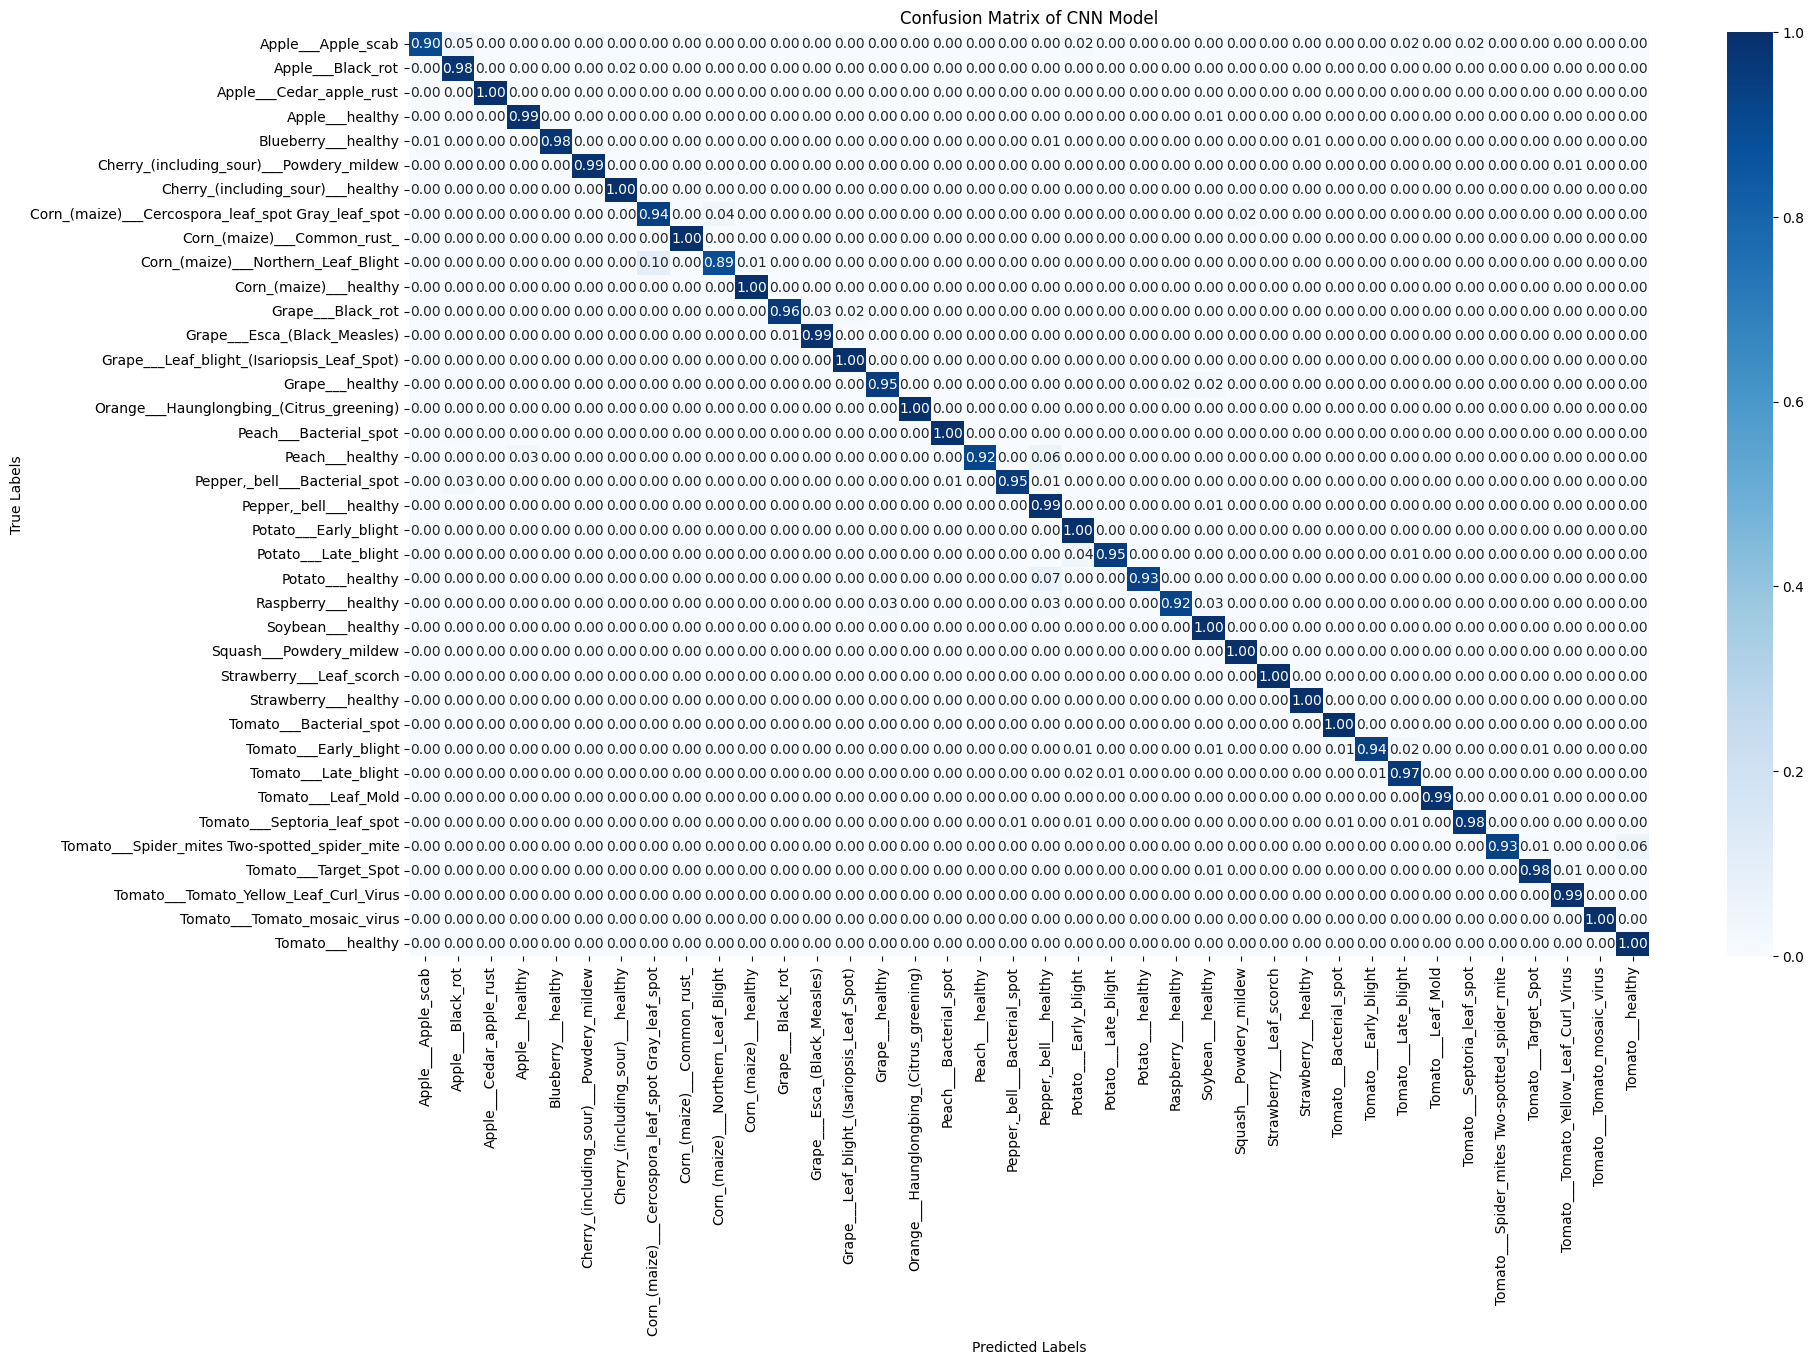


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.90      0.94        63
                                 Apple___Black_rot       0.90      0.98      0.94        62
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        27
                                   Apple___healthy       0.99      0.99      0.99       165
                               Blueberry___healthy       1.00      0.98      0.99       150
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       105
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.94      0.88        51
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       120
               Corn_(maize)___Northern_Leaf_Blight    

In [69]:
y_true = test_gen.classes

y_pred = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes,normalize='true')

class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(20, 12))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of CNN Model')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))
